## Learning MMD GAN on synthetic 2D data
This notebook is devoted to analyse the stability of learning an MMD GAN on synthetic 2D data . The effect of hyperparameters (including those of the kernel ) is in the scope of the notebook as well.

### Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

if torch.cuda.is_available():
    device = torch.device('cuda')
    dtype = torch.cuda.FloatTensor
else:
    device = torch.device('cpu')
    dtype = torch.FloatTensor

# If you don't want to bother with the device, stay on cpu:
# device = torch.device('cpu')

print(device)

cpu


### Target Measure

In the following cell, we define the discrete target measure $\nu$ that will serve as dataset for this practical session.

The variable `xgrid` contains a grid of points that will be useful below to display the discriminators along training.

In [21]:
d = 2   # dimension of the data points

# First dataset with 6 points
"""
n = 6
y = torch.zeros((n,d), device=device)
y[0, 0] = 0.9
y[0, 1] = 0.2
y[1, 0] = 0.75
y[1, 1] = 0.8
y[2, 0] = 0.3
y[2, 1] = 0.4
y[3, 0] = 0.4
y[3, 1] = 0.7
y[4, 0] = 0.45
y[4, 1] = 0.75
y[5, 0] = 0.7
y[5, 1] = 0.5


# Second dataset with 100 points
n = 100
t = torch.pi*torch.linspace(-.2,1.2,n)
y = .05*torch.randn((n,d))
y[:,0] += torch.cos(t)
y[:,1] += torch.sin(2*t)
y = .5 + .3*y
y = y.to(device)
# Define masses (empirical measure on the data points)
nu = torch.ones(n, device=device)/n

# generate grid for plotting purpose
nr,nc = 256,256
extent = ((-0.5/nc, 1-0.5/nc, 1-0.5/nr, -0.5/nr))
xs = torch.linspace(0, 1, steps=nr)
ys = torch.linspace(0, 1, steps=nc)
xm, ym = torch.meshgrid(xs, ys, indexing='ij')
xm = xm.T
ym = ym.T
xgrid = torch.cat((xm.reshape(nr*nc,1),ym.reshape(nr*nc,1)),1).to(device)

# Plot data points
fig = plt.figure(dpi=100)
plt.xticks([])
plt.yticks([])
plt.imshow(np.zeros((nr,nc)),cmap = 'Oranges', extent=extent) # background
plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
plt.show()
"""

"\nn = 6\ny = torch.zeros((n,d), device=device)\ny[0, 0] = 0.9\ny[0, 1] = 0.2\ny[1, 0] = 0.75\ny[1, 1] = 0.8\ny[2, 0] = 0.3\ny[2, 1] = 0.4\ny[3, 0] = 0.4\ny[3, 1] = 0.7\ny[4, 0] = 0.45\ny[4, 1] = 0.75\ny[5, 0] = 0.7\ny[5, 1] = 0.5\n\n\n# Second dataset with 100 points\nn = 100\nt = torch.pi*torch.linspace(-.2,1.2,n)\ny = .05*torch.randn((n,d))\ny[:,0] += torch.cos(t)\ny[:,1] += torch.sin(2*t)\ny = .5 + .3*y\ny = y.to(device)\n# Define masses (empirical measure on the data points)\nnu = torch.ones(n, device=device)/n\n\n#\xa0generate grid for plotting purpose\nnr,nc = 256,256\nextent = ((-0.5/nc, 1-0.5/nc, 1-0.5/nr, -0.5/nr))\nxs = torch.linspace(0, 1, steps=nr)\nys = torch.linspace(0, 1, steps=nc)\nxm, ym = torch.meshgrid(xs, ys, indexing='ij')\nxm = xm.T\nym = ym.T\nxgrid = torch.cat((xm.reshape(nr*nc,1),ym.reshape(nr*nc,1)),1).to(device)\n\n# Plot data points\nfig = plt.figure(dpi=100)\nplt.xticks([])\nplt.yticks([])\nplt.imshow(np.zeros((nr,nc)),cmap = 'Oranges', extent=extent) # ba

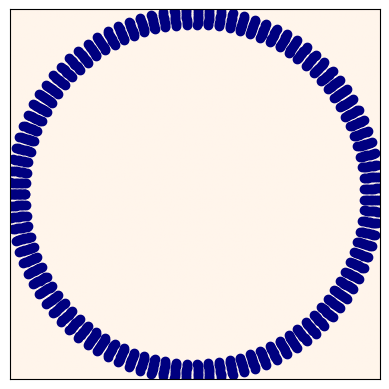

In [22]:
d = 2   # dimension of the data points

# First dataset with 6 points
"""
n = 6
y = torch.zeros((n,d), device=device)
y[0, 0] = 0.9
y[0, 1] = 0.2
y[1, 0] = 0.75
y[1, 1] = 0.8
y[2, 0] = 0.3
y[2, 1] = 0.4
y[3, 0] = 0.4
y[3, 1] = 0.7
y[4, 0] = 0.45
y[4, 1] = 0.75
y[5, 0] = 0.7
y[5, 1] = 0.5
"""
# Second dataset with 100 points
n = 100
tau=10
t = torch.pi*torch.linspace(-1,1,n)
y = torch.randn((tau*n,d))
for i in range (tau):
    y[i*n:(i+1)*n,0] = (10/(10+0.1*i))*torch.cos(t)
    y[i*n:(i+1)*n,1] = (10/(10+0.1*i))*torch.sin(t)

y = y.to(device)
# Define masses (empirical measure on the data points)
nu = torch.ones(n*tau, device=device)/n*tau

# generate grid for plotting purpose
nr,nc = 256,256
extent = ((-1, 1,-1, 1))
xs = torch.linspace(-1, 1, steps=nr)
ys = torch.linspace(-1, 1, steps=nc)
xm, ym = torch.meshgrid(xs, ys, indexing='ij')
xm = xm.T
ym = ym.T
xgrid = torch.cat((xm.reshape(nr*nc,1),ym.reshape(nr*nc,1)),1).to(device)

# Plot data points
fig = plt.figure(dpi=100)
plt.xticks([])
plt.yticks([])
plt.imshow(np.zeros((nr,nc)),cmap = 'Oranges', extent=extent) # background
plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
plt.show()

## Define Generator architecture



In [23]:
class Generator(torch.nn.Module):

    def __init__(self, n_in, n_out, n_hid=10, nlayers=3, device=torch.device("cpu")):
        super(Generator, self).__init__()

        self.n_in = n_in
        self.n_out = n_out
        self.n_hid = n_hid
        self.nlayers = nlayers
        self.hidden = nn.ModuleList()

        for n in range(nlayers):
            n_in_t = n_in if n==0 else n_hid
            self.hidden.append(nn.Sequential(
            nn.Linear(n_in_t, n_hid),
            nn.ELU(1)
        ).to(device))

        self.out = nn.Sequential(
            nn.Linear(n_hid, n_out),
            nn.Tanh()

        ).to(device)

        self.apply(self._init_weights)


    def forward(self, x):
        for n in range(self.nlayers):
            x = self.hidden[n](x)
        x = self.out(x)
        return x


    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, 1.0)
            if module.bias is not None:
                module.bias.data.zero_()


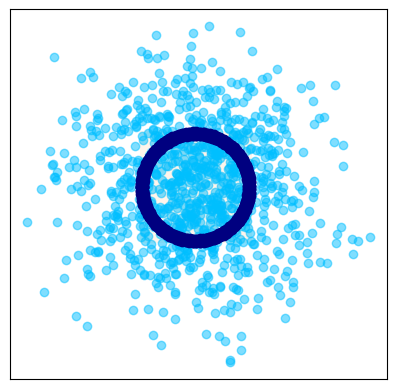

In [24]:
torch.manual_seed(0)  # initialize random seed for reproducibility

n_in = 10    # dimension of the input noise
b = 1000      # batch size

# Initialize generator
G = Generator(n_in=n_in, n_out=d, n_hid=100, nlayers=3, device=device)

# Draw a batch x of generated points
#    Input noise z : standard normal with shape (b, n_in)

x= torch.randn(b,n_in)

# Plot
xd = x.detach()
fig = plt.figure(dpi=100)
plt.xticks([])
plt.yticks([])
plt.imshow(np.zeros((nr,nc)),cmap = 'Oranges', extent=extent) # background
plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
plt.show()

## Define Discriminator Architecture

In [25]:
class Discriminator(nn.Module):
  def __init__(self, n_in, n_hid=10):
    super(Discriminator, self).__init__()

    self.n_hid = n_hid
    self.n_in = n_in

    self.fc1 = nn.Linear(n_in, n_hid)
    self.fc2 = nn.Linear(n_hid, n_hid)
    self.fc3 = nn.Linear(n_hid, 1)

  def forward(self, x):
    y = nn.LeakyReLU(negative_slope=0.2)(self.fc1(x))
    y = nn.LeakyReLU(negative_slope=0.2)(self.fc2(y))
    y = self.fc3(y)
    return y

## Training the generator using MMD


## Defining a kernel, and THE MMD from the kernel


In [26]:
def rbf(X, Y, sigma=2.0):
    """
    Computes the RBF (Gaussian) kernel matrix between two sets of points.
    K(x, y) = exp(- ||x - y||^2 / (2 * sigma^2))
    """
    X_size = X.size(0)
    Y_size = Y.size(0)

    X_ = X.unsqueeze(1)  # (X_size, 1, dim)
    Y_ = Y.unsqueeze(0)  # (1, Y_size, dim)

    # Calculate squared Euclidean distance: ||X_i - Y_j||^2
    # Resulting shape: (X_size, Y_size)
    dist_sq = (X_ - Y_).pow(2).sum(2)

    # Apply the RBF kernel formula
    return torch.exp(-dist_sq / (2 * sigma**2))

In [27]:
def MMD_from_k(k_func, X, Y, sigma=2.0):
    m = X.size(0)
    n = Y.size(0)

    K_XX = k_func(X, X, sigma) # m x m matrix of kernel evaluations between X and X
    K_YY = k_func(Y, Y, sigma) # n x n matrix of kernel evaluations between Y and Y
    K_XY = k_func(X, Y, sigma) # m x n matrix of kernel evaluations between X and Y

    # MMD^2 calculation using the biased estimator.
    # This directly corresponds to the empirical estimate of E[k(X,X')] + E[k(Y,Y')] - 2E[k(X,Y)],
    # which is derived from the optimal discriminator f*(x) = E[k(X,x)] - E[k(Y,x)] in its empirical form.
    MMD2 = K_XX.mean() + K_YY.mean() - 2 * K_XY.mean()

    # Use torch.relu to handle potential negative MMD2 due to numerical precision
    # and then take the square root to get MMD.
    return torch.sqrt(torch.relu(MMD2))

In [28]:
def optimal_MMD_descriminator(x,X,Y,k_func,sigma):
     opt_desc= k_func(x,X,sigma).mean(dim=1)-k_func(x,Y,sigma).mean(dim=1)
     return opt_desc

In [ ]:
## parameters for training
n_epochs = 100
niterD=1000
niterG=10
gpw = .1
k= rbf
lr = 0.002      # learning rate for generator
lrdisc = 0.002  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
sigma=2


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(k,fake_samples,y, sigma=sigma)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rbf,sigma).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

[1/100] 	Loss_G: 0.0668
[2/100] 	Loss_G: 0.0488
[3/100] 	Loss_G: 0.0181
[4/100] 	Loss_G: 0.0246
[5/100] 	Loss_G: 0.0133


### Visualization of Fake vs. Real Samples

In [ ]:
fig = plt.figure(dpi=100)
plt.xticks([])
plt.yticks([])
plt.imshow(D(xgrid).detach().cpu().numpy().reshape(nr,nc), cmap='Oranges', extent=extent) # Discriminator's output as background
plt.scatter(x[:, 0].detach().cpu(), x[:,1].detach().cpu(), c='deepskyblue', alpha=.5, label='Fake Samples')
plt.scatter(y[:, 0].cpu(), y[:,1].cpu(), c='navy', label='Real Samples')
plt.title('Current Distribution: Fake vs. Real Samples')
plt.legend()
plt.show()

## Comment on the learning process with $\sigma =2$
The quality of the training is poor, the generator failes to genrate points close to the original distribution. **This is because of the high value of $\sigma$**: the MMD loss takes a value close to $0$ values no matter if the generated ponts are close to the distribution of the original points or not.

#Kernel hyperparameters tuning

**$\sigma=0.5$**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rbf
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
sigma=0.5


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(k,fake_samples,y, sigma=sigma)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rbf,sigma).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

**$\sigma = 0.1$**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rbf
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
sigma=0.1


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(k,fake_samples,y, sigma=sigma)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rbf,sigma).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

**$σ=0.05$**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rbf
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
sigma=0.05


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(k,fake_samples,y, sigma=sigma)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rbf,sigma).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

**$\sigma=0.005$**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rbf
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
sigma=0.005


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(k,fake_samples,y, sigma=sigma)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rbf,sigma).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

The previous experiments show that the efficiency of the MMD Loss depends on the choice of $\sigma$ :  a very high or low value reduces the ability of discriminating fake samples and original samples .

Some questions raise from this analysis :     

Is it a good idea to change the value of $\sigma$ during the training?

is it possible to charachterize an "optimal" $\sigma$ ?

We remark as well that the generator tends to fill the space betwwwen close points , which might lead to some problems in learning non compact distributions, Can we link the quality of the generated samples to the "compacity/convexity" of the distribution?

## Using other kernels

**Rational quadratic kernel**

In [ ]:
def rat_quad_ker(X,Y,alpha):

    X_size = X.size(0)
    Y_size = Y.size(0)

    X_ = X.unsqueeze(1)  # (X_size, 1, dim)
    Y_ = Y.unsqueeze(0)  # (1, Y_size, dim)

    # Calculate squared Euclidean distance: ||X_i - Y_j||^2
    # Resulting shape: (X_size, Y_size)
    dist_sq = (X_ - Y_).pow(2).sum(2)

    # Apply the RBF kernel formula
    return (1+dist_sq/2*alpha)**-alpha



**$\alpha = 20$**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rat_quad_ker
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
alpha=20


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(rat_quad_ker,fake_samples,y, sigma=alpha)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rat_quad_ker,alpha).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

**$\alpha = 5$**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rat_quad_ker
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
alpha=5


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(rat_quad_ker,fake_samples,y, sigma=alpha)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rat_quad_ker,alpha).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())

**$\alpha = 0.1 $**

In [ ]:
## parameters for training
n_epochs = 300
niterD=1000
niterG=10
gpw = .1
k= rat_quad_ker
lr = 0.002      # learning rate for generator
  # learning rate for discriminator
beta_1 = 0.5
beta_2 = 0.999
alpha=0.1


torch.manual_seed(1)  # initialize random seed for reproducibility

# Initialize generators and discriminators
G = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
optimG = optim.Adam(G.parameters(), lr=lr)

D = Discriminator(n_in=d, n_hid=10).to(device)
optimD = optim.Adam(D.parameters(), lr=lrdisc, betas=(beta_1, beta_2))


Glosses = []
Dlosses = []

iter_display = 5

# Main loop
for epoch in range(1,n_epochs):

    ############################


    ############################
    ### Train generator (niterG iterations)
    ############################
    for iter in range(0,niterG):
        optimG.zero_grad()
        z = torch.randn(b, n_in, device=device)
        fake_samples = G(z)
        Gloss = MMD_from_k(rat_quad_ker,fake_samples,y, sigma=alpha)
        Gloss.backward()
        optimG.step()
        # define x for later stats/plotting

    # Output training stats
    # Replaced meanvariation with lipconstant as used in earlier cells, or we can just print the losses
    print('[%d/%d] 	Loss_G: %.4f'
      % (epoch, n_epochs, Gloss.item()))
    Glosses.append(Gloss.item())


    if(epoch % iter_display == 0):
        Dxgrid = optimal_MMD_descriminator(xgrid,y,fake_samples,rat_quad_ker,alpha).detach().cpu().numpy().reshape(nr,nc)
        z = torch.randn(b, n_in, device=device)
        x = G(z)
        xd = x.detach().squeeze(1)
        strtitle = 'Epoch '+str(epoch)
        fig = plt.figure(dpi=100)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(Dxgrid,cmap = 'Oranges', extent=extent)
        plt.scatter(xd[:, 0].cpu(), xd[:,1].cpu(),c='deepskyblue',alpha=.5)
        plt.scatter(y[:, 0].cpu(), y[:,1].cpu(),c='navy')
        plt.title(strtitle)
        plt.show()


plt.figure(dpi=100)
plt.plot(Glosses)
plt.title('Generator loss')
plt.show()

# Save final generator for later use
wgan = Generator(n_in=n_in, n_out=d, n_hid=10, nlayers=3, device=device)
wgan.load_state_dict(G.state_dict())